# 12｜从 11 的失败到 dispatch loss 试验

**目的**：11 说明点 MSE 和 `optimize_day` 优化的不是同一件事。本册用**同一套块和 + 窗排序损失**训练三个日级模型（Transformer / LSTM / DLinear），看 59 日真正进账能不能超过 11 的钱冠。

**输入**：

- 冻住的 11：`reports/holdout_rmse_v1/leaderboard.csv`、`reports/holdout_rmse_v2/leaderboard.csv`、`reports/holdout_rmse_v1/predictions.parquet`
- 本试验：`reports/holdout_dispatch_loss_v1/`（若没有则先跑 `experiments/holdout_dispatch_loss_v1/run.py`）

**验收标准**：

- 三条配方都有 pred_profit / realized / capture；
- 四张图写入 `outputs/notebooks/figures/nb12_*.png`；
- Headline 只比钱，不比 RMSE；通过线是 11 的钱冠 v2 Transformer（realized **6214**，capture **0.690**）；
- 不改 `reports/phase_b/final_metrics.json`，不改 v1/v2 的 RMSE 列，不把 59 天写成新冠军。

**口径**：官方分数 `sum(price × power)`，不是人民币。`capture = realized / oracle`。Oracle 是看见当天真 `A` 再穷举 3321 个合法 8+8 窗的上界，59 日均 **9000.89**，各模型相同。realized 和 capture 排序永远一样。

**协议**：271 训 / 30 日 realized 选 \((\lambda, \tau)\) / 301 重训 / 59 只考一次。Early stop 不看 RMSE。选格也用了 30 日 realized，所以相对 11 的提升会把「换损失」和「换选模尺子」混在一起。


## 核心结案（先读这个）

- **相对 11 的钱冠，dispatch loss 有效。** 最好的新配方是 **`lstm_dispatch`**：realized **6301**，capture **0.700**，pred_profit **6988**。11 钱冠 v2 Transformer 是 6214 / 0.690 / pred 10527。
- **惊喜在 LSTM。** 11 里 v1 LSTM 是最差光滑器（4554 / 0.506）；同一头换成窗排序损失后涨到 6301 / 0.700。
- **Transformer 贴着钱冠。** `transformer_dispatch` realized **6214**、capture **0.690**，和 v2 MSE Transformer 几乎同一条线；pred_profit 只有 6740，gap 小，不再是「以为能赚很多」。它只训了 2 个 epoch（30 日 realized 在 epoch 2 最高），RMSE 1.62，再次说明点误差不是钱。
- **DLinear 没有惊喜。** `dlinear_dispatch` realized **5538**、capture **0.615**，低于气候平均，pred 8710、gap 大。
- **59 天不是新冠军。** 这段已经在 11 露过面。本册只回答方法有没有比 11 钱冠更赚钱。不刷新 35 配方总榜，不改 Phase B 冻结数。


In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from matplotlib import font_manager


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'phase_b').is_dir():
            return candidate
    raise FileNotFoundError('请从 Southern_Electricity 仓库内启动 notebook')


def show_figure(path: Path) -> None:
    display(Image(filename=str(path)))


_cjk = next(
    (name for name in ('Microsoft YaHei', 'SimHei', 'Microsoft JhengHei')
     if any(font.name == name for font in font_manager.fontManager.ttflist)),
    None,
)
if _cjk:
    plt.rcParams['font.sans-serif'] = [_cjk, 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

REPO_ROOT = find_repo_root()
os.environ.setdefault('MPLCONFIGDIR', str(REPO_ROOT / '.matplotlib_cache'))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES = REPO_ROOT / 'outputs' / 'notebooks' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
REPORT = REPO_ROOT / 'reports' / 'holdout_dispatch_loss_v1'
PHASE_B = REPO_ROOT / 'reports' / 'phase_b' / 'final_metrics.json'
MONEY_LINE_REALIZED = 6214.361782
MONEY_LINE_CAPTURE = 0.690417
print({'repo_root': str(REPO_ROOT), 'figures': str(FIGURES.relative_to(REPO_ROOT))})


{'repo_root': '<repo>', 'figures': 'outputs\\notebooks\\figures'}


## 1. 11 留下的问题

点 MSE 平均 96 个槽；`optimize_day` 只比较 3321 个合法 8+8 窗。v1 Transformer RMSE 0.514、realized 5637（贴气候平均 5644）；v2 Transformer RMSE 0.631、realized **6214**。v1 LSTM 是最差光滑器（4554 / 0.506）。本册不换架构，只换损失，三个 compact 头都跑。


## 2. 新损失（对照 `F.mse_loss`）

原来：`L = mean((ŷ − A)²)` 遍 96 点。

现在：先减日均，再对 89 个 8 格块和做 MSE，并让预测窗分把**当天训练集真 A 的最优窗**排第一：

$$L = \mathrm{MSE}(\hat S, S) + \lambda\,\mathrm{CE}(\hat s / \tau,\, w^\star)$$

其中 \(s(t_c,t_d)=S_{t_d}-S_{t_c}\)，**不乘 1000**。\(w^\star\) 只来自训练日真价。树模型没有这套可导 softmax，本册不硬塞。


In [2]:
import inspect
from experiments.holdout_dispatch_loss_v1.loss import dispatch_loss

print(inspect.getsource(dispatch_loss))


def dispatch_loss(
    pred: torch.Tensor,
    y: torch.Tensor,
    *,
    lam: float = 0.5,
    tau: float = 0.1,
) -> torch.Tensor:
    """Block-sum MSE plus window ranking CE.

    ``pred`` and ``y`` are ``(batch, 96)`` absolute prices. Oracle labels come
    from ``y`` only and do not receive gradients. Idle is ignored: the target
    is always the best active window on that training day.
    """

    if pred.shape != y.shape:
        raise ValueError(f"pred shape {tuple(pred.shape)} != y shape {tuple(y.shape)}")
    if tau <= 0:
        raise ValueError("tau must be positive")
    if lam < 0:
        raise ValueError("lam must be non-negative")

    pred_c = day_center(pred)
    y_c = day_center(y)
    hat_blocks = block_sums(pred_c)
    true_blocks = block_sums(y_c)
    loss_block = F.mse_loss(hat_blocks, true_blocks)

    hat_scores = window_scores(hat_blocks)
    oracle = oracle_window_index(y)
    loss_rank = F.cross_entropy(hat_scores / tau, oracle)
    return loss_block + fl

In [ ]:
board_path = REPORT / 'leaderboard.csv'
# Published copy is read-only: it never launches training. Frozen experiment outputs
# under reports/ are not distributed with this repository -- see DATA.md for how to
# regenerate them from the source data before running this notebook.
assert board_path.exists(), (
    f'missing {board_path}. This notebook reads frozen experiment outputs only; '
    'it does not train. See DATA.md to obtain the data and regenerate reports/.'
)
print('loading frozen trial artifacts from', REPORT.relative_to(REPO_ROOT))

trial = pd.read_csv(REPORT / 'leaderboard.csv')
ok = trial[trial['status'] == 'ok'].copy()
assert len(ok) == 3, f'expected 3 ok recipes, got {len(ok)}: {trial["status"].tolist()}'
selection = json.loads((REPORT / 'selection.json').read_text(encoding='utf-8'))
manifest = json.loads((REPORT / 'manifest.json').read_text(encoding='utf-8'))
assert manifest.get('holdout_not_used_for_selection') is True
print(ok[['model', 'lam', 'tau', 'pred_profit_mean', 'realized_profit_mean', 'capture']].to_string(index=False))
print('phase_b frozen file still exists:', PHASE_B.exists())


In [4]:
v1 = pd.read_csv(REPO_ROOT / 'reports' / 'holdout_rmse_v1' / 'leaderboard.csv')
v2 = pd.read_csv(REPO_ROOT / 'reports' / 'holdout_rmse_v2' / 'leaderboard.csv')


def _anchor(frame: pd.DataFrame, model: str, version: str) -> dict:
    row = frame.loc[frame['model'] == model].iloc[0]
    return {
        'source': version,
        'recipe': f'{version}/{model}',
        'pred_profit_mean': float(row['pred_profit_mean']),
        'realized_profit_mean': float(row['realized_profit_mean']),
        'capture': float(row['capture']),
        'profit_gap': float(row['profit_gap']),
        'oracle_profit_mean': float(row['oracle_profit_mean']),
        'RMSE': float(row['RMSE']),
    }


anchors = [
    _anchor(v2, 'transformer_contextual', 'v2'),
    _anchor(v1, 'transformer_contextual', 'v1'),
    _anchor(v1, 'lstm_contextual', 'v1'),
    _anchor(v1, 'climatology_weekday_slot', 'v1'),
]
new_rows = []
for _, row in ok.iterrows():
    new_rows.append({
        'source': 'nb12',
        'recipe': row['model'],
        'pred_profit_mean': float(row['pred_profit_mean']),
        'realized_profit_mean': float(row['realized_profit_mean']),
        'capture': float(row['capture']),
        'profit_gap': float(row['profit_gap']),
        'oracle_profit_mean': float(row['oracle_profit_mean']),
        'RMSE': float(row['RMSE']),
        'lam': float(row['lam']),
        'tau': float(row['tau']),
    })
compare = pd.DataFrame(anchors + new_rows)
best_new = ok.loc[ok['realized_profit_mean'].idxmax()]
beat = float(best_new['realized_profit_mean']) > MONEY_LINE_REALIZED
lstm_new = ok.loc[ok['model'] == 'lstm_dispatch'].iloc[0]
lstm_old = float(v1.loc[v1['model'] == 'lstm_contextual', 'realized_profit_mean'].iloc[0])

if beat:
    verdict = (
        f"相对 11 的钱冠，dispatch loss 有效。"
        f"最好的新配方是 {best_new['model']}：realized {float(best_new['realized_profit_mean']):.0f}，"
        f"capture {float(best_new['capture']):.3f}（通过线 6214 / 0.690）。"
    )
else:
    verdict = (
        f"损失对齐了 8+8，这次试验还没打过 11 的钱冠。"
        f"最好的新配方是 {best_new['model']}：realized {float(best_new['realized_profit_mean']):.0f}，"
        f"capture {float(best_new['capture']):.3f}，对照 v2 Transformer 6214 / 0.690。"
    )
verdict += (
    f" LSTM 从 v1 MSE 的 {lstm_old:.0f} 到 dispatch 的 {float(lstm_new['realized_profit_mean']):.0f}。"
    " 59 天不是新冠军。"
)
display(Markdown(f"**结案：** {verdict}"))
print(verdict)


**结案：** 相对 11 的钱冠，dispatch loss 有效。最好的新配方是 lstm_dispatch：realized 6301，capture 0.700（通过线 6214 / 0.690）。 LSTM 从 v1 MSE 的 4554 到 dispatch 的 6301。 59 天不是新冠军。

相对 11 的钱冠，dispatch loss 有效。最好的新配方是 lstm_dispatch：realized 6301，capture 0.700（通过线 6214 / 0.690）。 LSTM 从 v1 MSE 的 4554 到 dispatch 的 6301。 59 天不是新冠军。


## 3. Headline 对照：pred_profit / realized / capture

通过线画在 v2 Transformer。RMSE 只留在表里当附录，不参与判定。


In [5]:
show = compare.copy()
show['pred_profit'] = show['pred_profit_mean'].round(0).astype(int)
show['realized'] = show['realized_profit_mean'].round(0).astype(int)
show['capture'] = show['capture'].round(3)
show['gap'] = show['profit_gap'].round(0).astype(int)
show['rmse'] = show['RMSE'].round(3)
show['beat_v2_tf'] = show['realized_profit_mean'] > MONEY_LINE_REALIZED
display(
    show[['source', 'recipe', 'pred_profit', 'realized', 'capture', 'gap', 'rmse', 'beat_v2_tf']]
    .sort_values('realized', ascending=False)
    .style.format({'capture': '{:.3f}', 'rmse': '{:.3f}'})
    .hide(axis='index')
)


source,recipe,pred_profit,realized,capture,gap,rmse,beat_v2_tf
nb12,lstm_dispatch,6988,6301,0.700,686,0.859,True
nb12,transformer_dispatch,6740,6214,0.690,526,1.621,False
v2,v2/transformer_contextual,10527,6214,0.690,4313,0.631,False
v1,v1/climatology_weekday_slot,8283,5644,0.627,2638,0.895,False
v1,v1/transformer_contextual,6627,5637,0.626,990,0.514,False
nb12,dlinear_dispatch,8710,5538,0.615,3172,0.885,False
v1,v1/lstm_contextual,6350,4554,0.506,1796,0.574,False


outputs\notebooks\figures\nb12_fig1_realized_capture.png


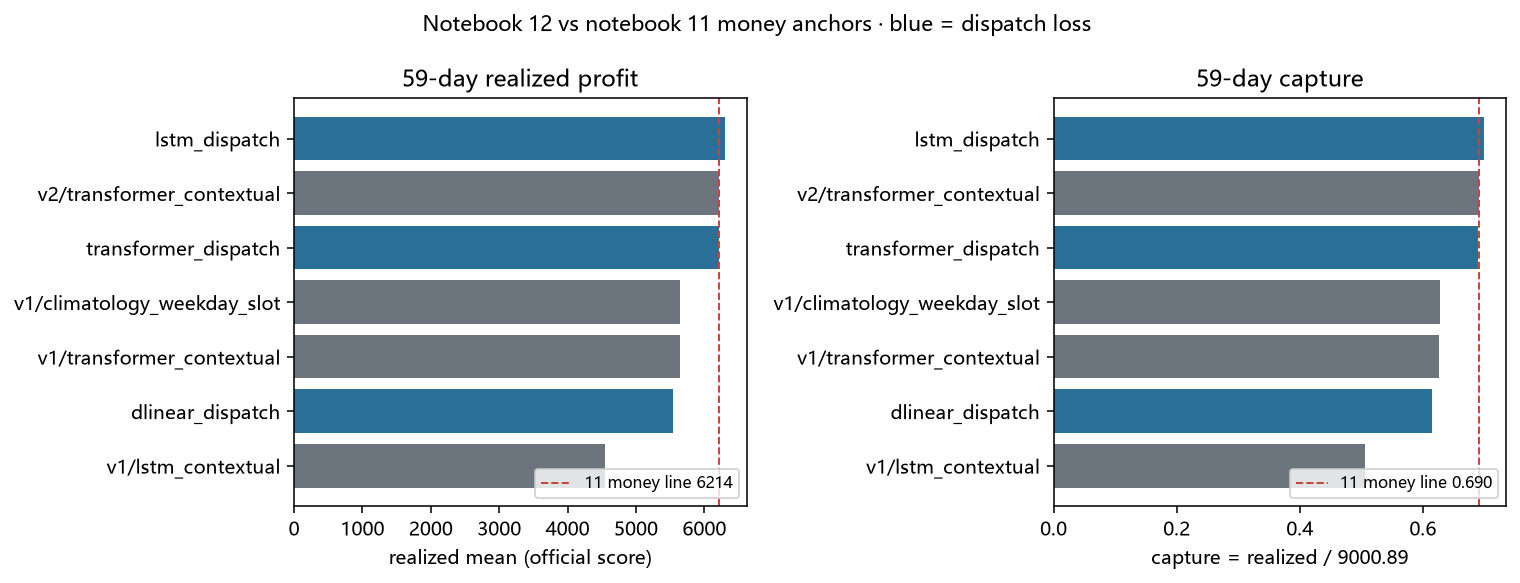

In [6]:
order = compare.sort_values('realized_profit_mean', ascending=False)
colors = ['#2a6f97' if src == 'nb12' else '#6c757d' for src in order['source']]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].barh(order['recipe'], order['realized_profit_mean'], color=colors)
axes[0].axvline(MONEY_LINE_REALIZED, color='#c44536', linestyle='--', linewidth=1, label='11 money line 6214')
axes[0].set_xlabel('realized mean (official score)')
axes[0].set_title('59-day realized profit')
axes[0].invert_yaxis()
axes[0].legend(loc='lower right', fontsize=8)
axes[1].barh(order['recipe'], order['capture'], color=colors)
axes[1].axvline(MONEY_LINE_CAPTURE, color='#c44536', linestyle='--', linewidth=1, label='11 money line 0.690')
axes[1].set_xlabel('capture = realized / 9000.89')
axes[1].set_title('59-day capture')
axes[1].invert_yaxis()
axes[1].legend(loc='lower right', fontsize=8)
fig.suptitle('Notebook 12 vs notebook 11 money anchors · blue = dispatch loss', fontsize=11)
fig.tight_layout()
p1 = FIGURES / 'nb12_fig1_realized_capture.png'
fig.savefig(p1, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p1.relative_to(REPO_ROOT))
show_figure(p1)


outputs\notebooks\figures\nb12_fig2_pred_vs_realized.png


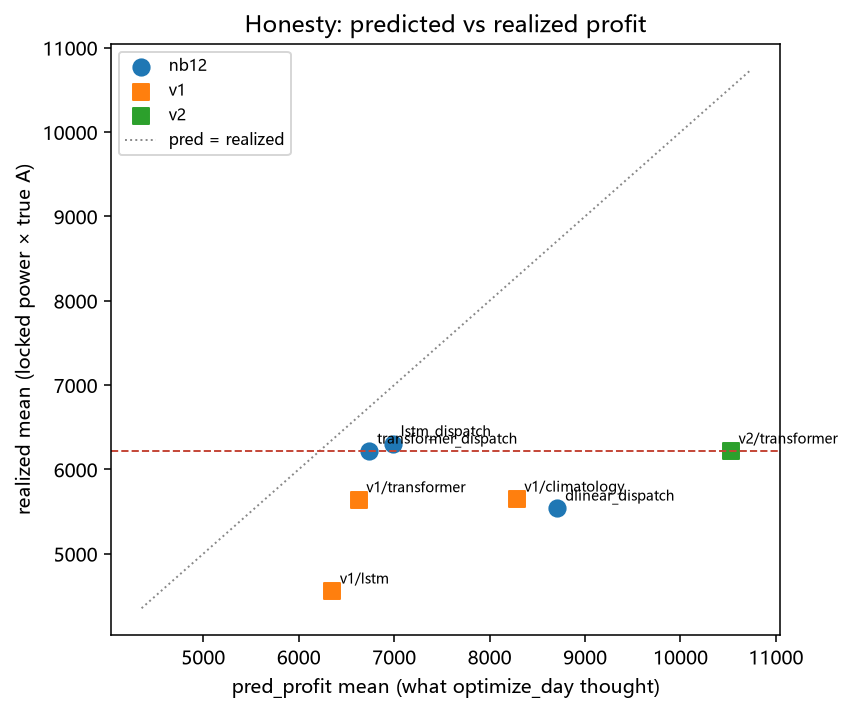

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
for src, sub in compare.groupby('source'):
    marker = 'o' if src == 'nb12' else 's'
    ax.scatter(
        sub['pred_profit_mean'],
        sub['realized_profit_mean'],
        s=70,
        marker=marker,
        label=src,
    )
    for _, row in sub.iterrows():
        ax.annotate(row['recipe'].replace('_contextual', '').replace('_weekday_slot', ''),
                    (row['pred_profit_mean'], row['realized_profit_mean']),
                    fontsize=7, xytext=(4, 4), textcoords='offset points')
lims = [
    min(compare['pred_profit_mean'].min(), compare['realized_profit_mean'].min()) - 200,
    max(compare['pred_profit_mean'].max(), compare['realized_profit_mean'].max()) + 200,
]
ax.plot(lims, lims, color='#888', linewidth=1, linestyle=':', label='pred = realized')
ax.axhline(MONEY_LINE_REALIZED, color='#c44536', linestyle='--', linewidth=1)
ax.set_xlabel('pred_profit mean (what optimize_day thought)')
ax.set_ylabel('realized mean (locked power × true A)')
ax.set_title('Honesty: predicted vs realized profit')
ax.legend(fontsize=8)
fig.tight_layout()
p2 = FIGURES / 'nb12_fig2_pred_vs_realized.png'
fig.savefig(p2, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p2.relative_to(REPO_ROOT))
show_figure(p2)


## 4. 11 里亏钱的一天（2025-12-12）和新模型

v1 Transformer 那天 realized −5343。看 dispatch loss 最好的那条曲线是否还把窗坐进谷里。


outputs\notebooks\figures\nb12_fig3_dec12.png


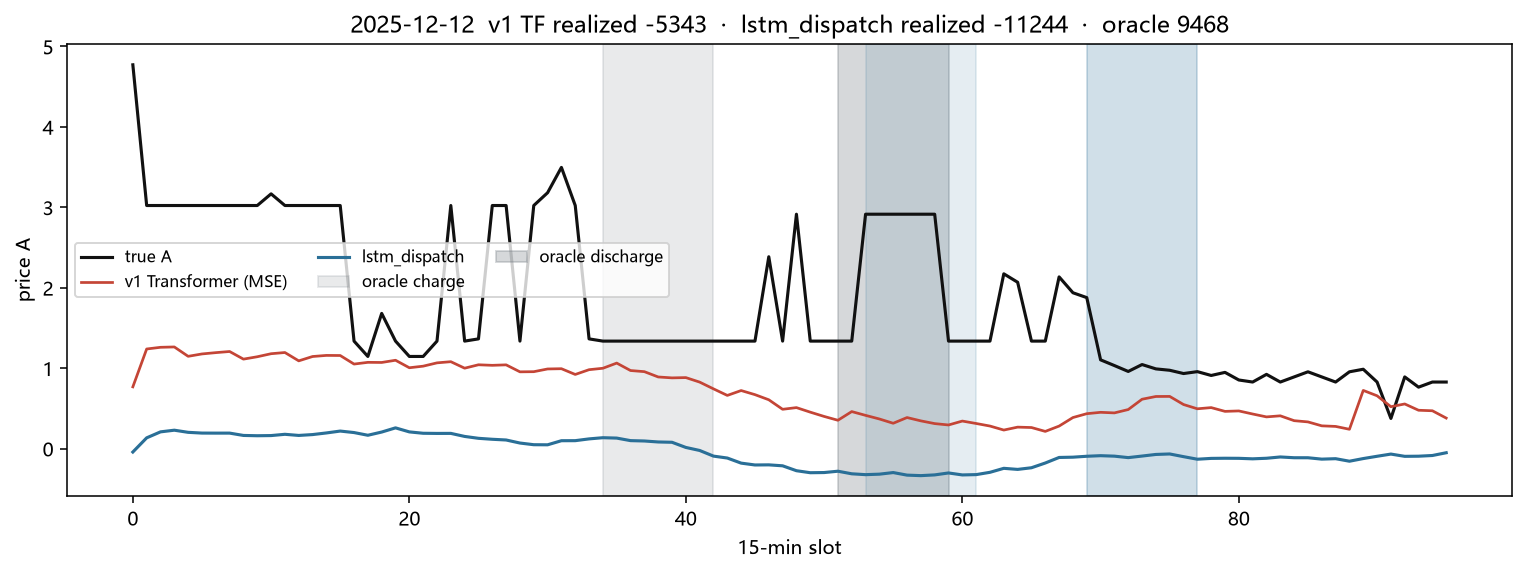

In [8]:
from src.phase_b.dispatch import optimize_day
from src.phase_b.evaluation import score_day

v1_pred = pd.read_parquet(REPO_ROOT / 'reports' / 'holdout_rmse_v1' / 'predictions.parquet')
trial_pred = pd.read_parquet(REPORT / 'predictions.parquet')
best_name = str(best_new['model'])
time_col = 'times' if 'times' in v1_pred.columns else v1_pred.columns[0]
day = pd.Timestamp('2025-12-12')
v1_day = v1_pred.loc[pd.to_datetime(v1_pred[time_col]).dt.normalize() == day].copy()
tr_day = trial_pred.loc[pd.to_datetime(trial_pred['times']).dt.normalize() == day].copy()
actual = v1_day['A'].to_numpy(dtype=float) if 'A' in v1_day.columns else tr_day['A'].to_numpy(dtype=float)
old = v1_day['transformer_contextual'].to_numpy(dtype=float)
new = tr_day[best_name].to_numpy(dtype=float)
slots = np.arange(96)
old_dec = optimize_day(old)
new_dec = optimize_day(new)
ora = optimize_day(actual)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(slots, actual, color='#111', linewidth=1.6, label='true A')
ax.plot(slots, old, color='#c44536', linewidth=1.4, label='v1 Transformer (MSE)')
ax.plot(slots, new, color='#2a6f97', linewidth=1.6, label=best_name)
if ora.tc is not None:
    ax.axvspan(ora.tc, ora.tc + 8, color='#6c757d', alpha=0.15, label='oracle charge')
    ax.axvspan(ora.td, ora.td + 8, color='#6c757d', alpha=0.28, label='oracle discharge')
if new_dec.tc is not None:
    ax.axvspan(new_dec.tc, new_dec.tc + 8, color='#2a6f97', alpha=0.12)
    ax.axvspan(new_dec.td, new_dec.td + 8, color='#2a6f97', alpha=0.22)
ax.set_xlabel('15-min slot')
ax.set_ylabel('price A')
ax.set_title(
    f'2025-12-12  v1 TF realized {score_day(actual, old_dec.power):.0f}  ·  '
    f'{best_name} realized {score_day(actual, new_dec.power):.0f}  ·  '
    f'oracle {score_day(actual, ora.power):.0f}'
)
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
p3 = FIGURES / 'nb12_fig3_dec12.png'
fig.savefig(p3, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p3.relative_to(REPO_ROOT))
show_figure(p3)


## 5. 30 日选格（holdout 没用过）

每个模型在 271 上训、在 30 日 realized 上选 \((\lambda, \tau)\)。下面是选格，不是 59 日成绩。


family,lam,tau,val30_realized,best_epoch,status,chosen
dlinear,0.500000,0.200000,7393.406995,23,ok,True
dlinear,1.000000,0.100000,7016.350220,17,ok,False
dlinear,0.500000,0.100000,6973.895311,1,ok,False
lstm,0.500000,0.200000,8639.142213,31,ok,True
lstm,0.500000,0.100000,8276.893176,10,ok,False
lstm,1.000000,0.100000,7529.303954,1,ok,False
transformer,0.500000,0.200000,8341.772709,2,ok,True
transformer,1.000000,0.100000,8315.891260,7,ok,False
transformer,0.500000,0.100000,8001.613067,6,ok,False


outputs\notebooks\figures\nb12_fig4_val30_grid.png


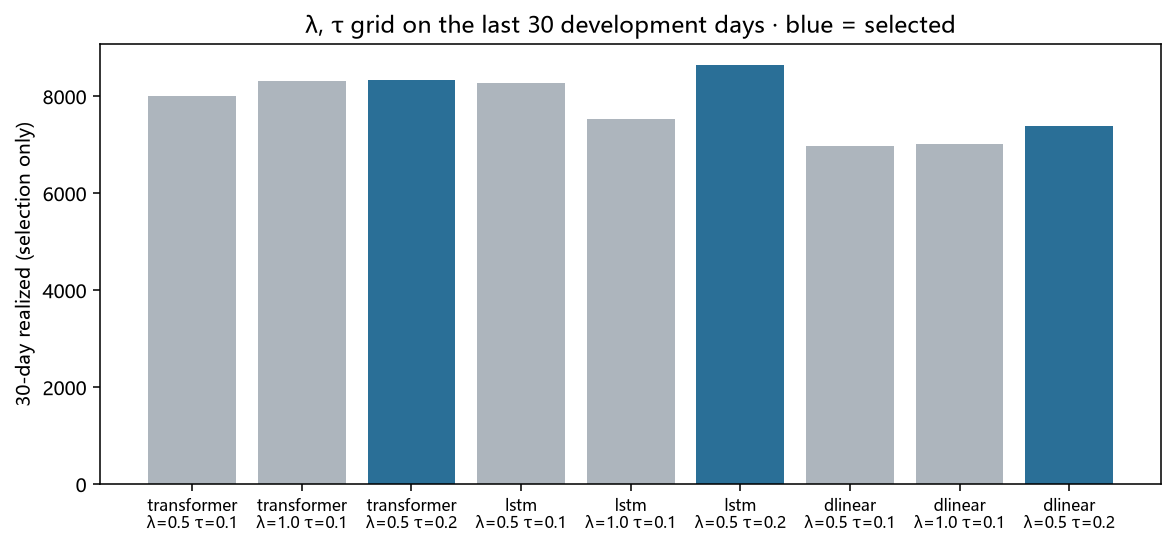

In [9]:
grid_rows = []
for family, payload in selection.items():
    for point in payload.get('grid', []):
        grid_rows.append({
            'family': family,
            'lam': point.get('lam'),
            'tau': point.get('tau'),
            'val30_realized': point.get('val30_realized'),
            'best_epoch': point.get('best_epoch'),
            'status': point.get('status'),
            'chosen': (
                point.get('lam') == payload.get('lam')
                and point.get('tau') == payload.get('tau')
                and point.get('status') == 'ok'
            ),
        })
grid = pd.DataFrame(grid_rows)
display(grid.sort_values(['family', 'val30_realized'], ascending=[True, False]).style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(8.5, 4.0))
labels = [f"{r.family}\nλ={r.lam} τ={r.tau}" for r in grid.itertuples()]
vals = grid['val30_realized'].astype(float).to_numpy()
bar_colors = ['#2a6f97' if chosen else '#adb5bd' for chosen in grid['chosen']]
ax.bar(np.arange(len(grid)), vals, color=bar_colors)
ax.set_xticks(np.arange(len(grid)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('30-day realized (selection only)')
ax.set_title('λ, τ grid on the last 30 development days · blue = selected')
fig.tight_layout()
p4 = FIGURES / 'nb12_fig4_val30_grid.png'
fig.savefig(p4, dpi=140, bbox_inches='tight')
plt.close(fig)
print(p4.relative_to(REPO_ROOT))
show_figure(p4)


## 6. 这 59 天不是新冠军

Holdout 已经在 11 里露过面。本册只回答：把训练目标换成 8+8 窗排序之后，三个日级模型有没有比 11 的钱冠更赚钱。不刷新 35 配方总榜，不改 Phase B 冻结数，不在这 59 天上再拧 \(\lambda\)。
